In [6]:
import duckdb as duckdb
from dotenv import load_dotenv
import os

load_dotenv()

True

In [7]:
db_path = os.getenv("DB_PATH")
data_path = os.getenv("DATA_PATH")

In [12]:
query = f"""
SELECT 
      FLOOR(t.temperatura) AS temp_int,
      AVG(c.valor) AS consumo_promedio
  FROM read_parquet('{data_path}') c
  JOIN temp_departamento t
      ON c.dia = t.dia
     AND c.hora = t.hora
     AND c.departamento = t.departamento
  WHERE c.departamento = 'MONTEVIDEO'
  GROUP BY temp_int
  ORDER BY temp_int;
"""

con = duckdb.connect(database= db_path)
result = con.query(query).to_df()


In [11]:
result.head()

,temp_int,consumo_promedio
0,-4.0,0.561879
1,-3.0,0.453365
2,-2.0,0.494804
3,-1.0,0.477605
4,0.0,0.483324


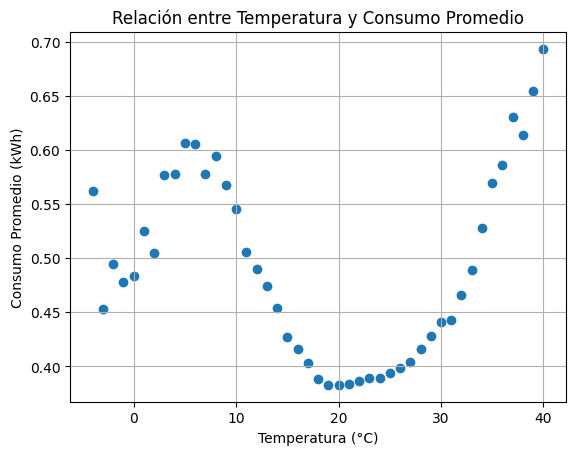

In [10]:
#print all the results, temp_int en x-axis y consumo promedio en y-axis
import matplotlib.pyplot as plt

plt.scatter(result['temp_int'], result['consumo_promedio'])
plt.xlabel('Temperatura (°C)')
plt.ylabel('Consumo Promedio (kWh)')
plt.title('Relación entre Temperatura y Consumo Promedio')
plt.grid()
plt.show()